In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [44]:
data = pd.read_csv("house_price.csv")

In [29]:
data.describe()

,area,rooms,price
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    47 non-null     int64
 1   rooms   47 non-null     int64
 2   price   47 non-null     int64
dtypes: int64(3)
memory usage: 1.2 KB


In [31]:
data.columns

Index(['area', 'rooms', 'price'], dtype='object')

**Exploratory Data Analysis (EDA)**

**PAIRPLOT**
Used to visually explore the relationships between multiple numerical variables at once. It helps you see whether relationships look positive, negative, weak, or strong.
It also shows the distribution of each individual variable along the diagonal.

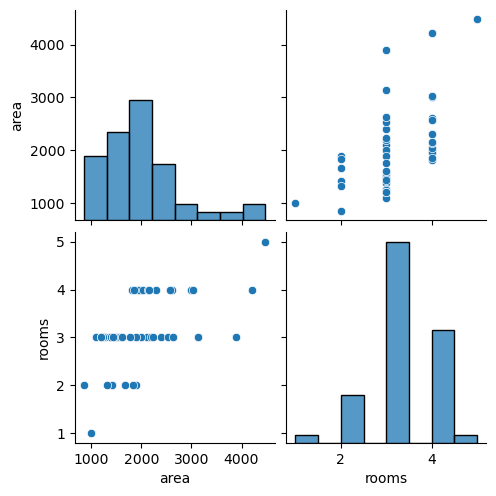

In [32]:
sns.pairplot(data[['area', 'rooms']])

**.corr()**
.corr() is a Pandas DataFrame method. It calculates the correlation between numerical columns.
Your area–price correlation is 0.85, which indicates a strong positive linear relationship.
Your rooms–price correlation is 0.44, which is a weaker/moderate positive relationship.

In [67]:
data[['area', 'rooms', 'price']].corr()

,area,rooms,price
area,1.000000,0.559967,0.854988
rooms,0.559967,1.000000,0.442261
price,0.854988,0.442261,1.000000


**HEATMAP**
Heatmap is only a visual way to display the correlation matrix. It makes it easier to spot stronger/weaker correlations when you have many features.

<Axes: >

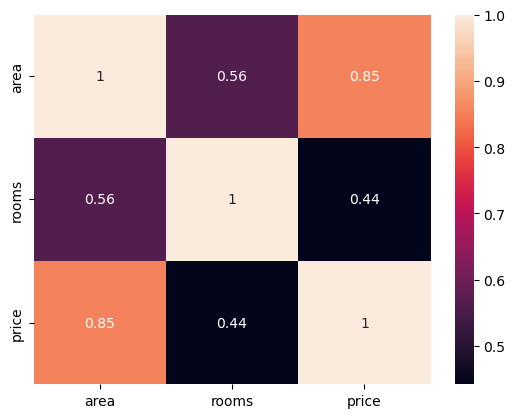

In [68]:
sns.heatmap(data[['area', 'rooms', 'price']].corr(), annot=True)

**Box plot → "Are there outliers?"**

Why do we do this now?

Because before training Linear Regression, we want to know whether some observations are extremely different from the rest.

For example:

One house might have an unusually huge area.
One house might have an unusually high price.

Such observations can have a significant effect on a linear regression model.

<Axes: >

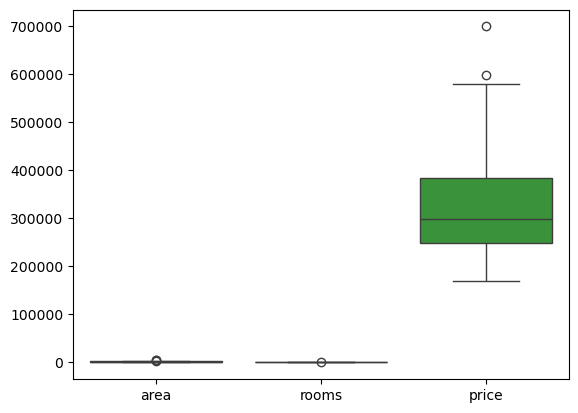

In [70]:
sns.boxplot(data=data[['area', 'rooms', 'price']])

**We use separate box plots for each feature because the features have different scales. A combined box plot can hide outliers in smaller-scale features, so separate plots allow us to examine the distribution and outliers of each feature clearly.**

<Axes: xlabel='area'>

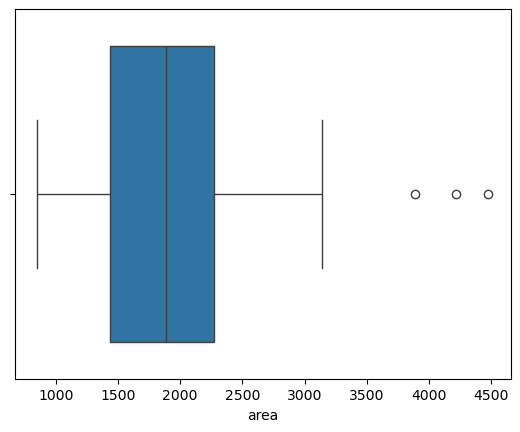

In [71]:
sns.boxplot(x=data['area'])

<Axes: xlabel='rooms'>

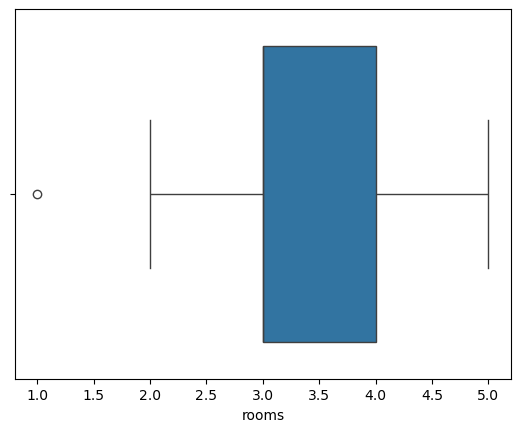

In [72]:
sns.boxplot(x=data['rooms'])

**Outlier ≠ bad data.
Data error → potentially remove.
Genuine unusual observation → usually keep.**

**SCATTERPLOT**
A scatter plot is used to visualize the **relationship between two numerical variables**.

In this dataset, we used scatter plots to compare:

* `area` vs `price`
* `rooms` vs `price`

### **Observations**

* **Area vs Price:** The points show an overall upward trend, indicating a **stronger positive relationship** between area and price.
* **Rooms vs Price:** The points form separate groups because `rooms` contains discrete values (1, 2, 3, 4, 5). The relationship with price appears **weaker** than area vs price.

### **Conclusion**

`area` appears to be a more useful feature for predicting `price` than `rooms`, based on the scatter plots and the correlation values.



<Axes: xlabel='area', ylabel='price'>

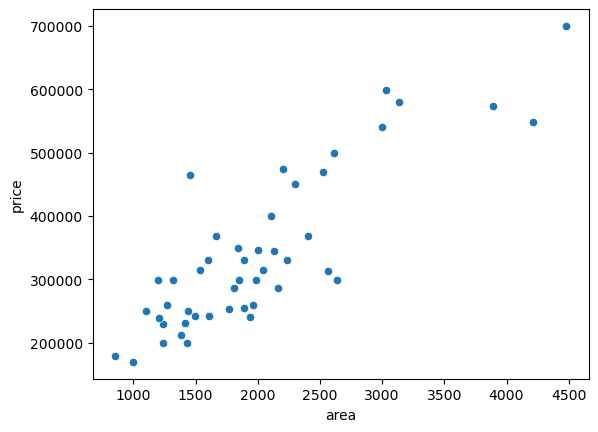

In [33]:
sns.scatterplot(data=data, x='area', y='price')

<Axes: xlabel='rooms', ylabel='price'>

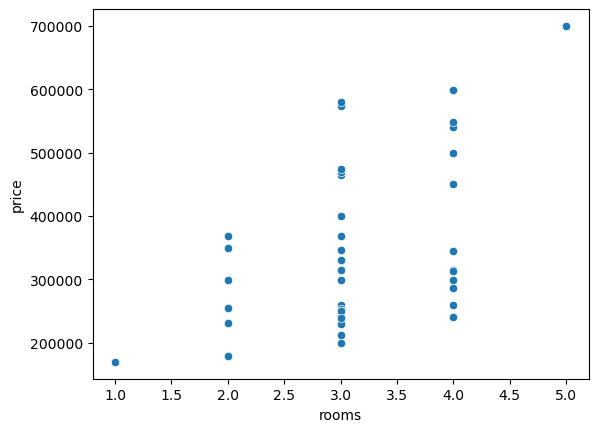

In [73]:
sns.scatterplot(data=data, x='rooms', y='price')

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [46]:
X = data[['area', 'rooms']]
y = data['price']

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state =42)

In [48]:
model = LinearRegression()

In [49]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred = model.predict(X_test)

In [51]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

In [52]:
mse_fea = mean_squared_error(y_test,y_pred)
rmse_fea =  root_mean_squared_error(y_test,y_pred)
r2_fea = r2_score(y_test,y_pred)

In [53]:
print(mse)

7611089615.010203


In [54]:
print(rmse)

87241.5589900261


In [55]:
print(r2)

0.5888107938859346


## **Feature Engineering**

Feature engineering is the process of **creating new features from existing features** to provide the model with potentially useful information.

In this project, we created:

```python
data['area_per_room'] = data['area'] / data['rooms']
```

We created this feature because `area` and `rooms` individually may not fully represent how spacious a house is.

`area_per_room` provides additional information about the **amount of area available per room**.

We then compared the model's performance **before and after feature engineering** to check whether the new feature improved the model.


In [53]:
data['area_per_room'] = data['area']/data['rooms']

In [54]:
data['area_squared'] = data['area']*data['area']

In [55]:
data.head

<bound method NDFrame.head of     area  rooms   price  area_per_room  area_squared
0   2104      3  399900     701.333333       4426816
1   1600      3  329900     533.333333       2560000
2   2400      3  369000     800.000000       5760000
3   1416      2  232000     708.000000       2005056
4   3000      4  539900     750.000000       9000000
5   1985      4  299900     496.250000       3940225
6   1534      3  314900     511.333333       2353156
7   1427      3  198999     475.666667       2036329
8   1380      3  212000     460.000000       1904400
9   1494      3  242500     498.000000       2232036
10  1940      4  239999     485.000000       3763600
11  2000      3  347000     666.666667       4000000
12  1890      3  329999     630.000000       3572100
13  4478      5  699900     895.600000      20052484
14  1268      3  259900     422.666667       1607824
15  2300      4  449900     575.000000       5290000
16  1320      2  299900     660.000000       1742400
17  1236      3 

In [56]:
X = data[['area', 'rooms', 'area_per_room', 'area_squared']]
y = data['price']

In [57]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state =42)

In [58]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
y_pred_fea = model.predict(X_test)

In [60]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
mse_fea = mean_squared_error(y_test,y_pred)
rmse_fea =  root_mean_squared_error(y_test,y_pred)
r2_fea = r2_score(y_test,y_pred)

In [23]:
print(mse)

7222887196.503413


In [24]:
print(rmse)

84987.57083540753


In [25]:
print(r2)

0.6097834341190183


In [62]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
27,469000,392338.906658
39,287000,341785.077857
26,464500,252300.038331
43,299000,218470.424073
24,573900,571190.045607
36,229900,223584.202972
12,329999,308944.973834
19,599000,455730.561543
4,539900,451665.762930
25,249900,205358.170484


In [63]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_fea
})

comparison.head(10)

,Actual,Predicted
27,469000,396908.777625
39,287000,336144.564818
26,464500,258302.538536
43,299000,223176.713082
24,573900,558005.718613
36,229900,228527.432112
12,329999,315686.935623
19,599000,459191.196438
4,539900,454926.438738
25,249900,209390.193490


## **Feature Scaling**

Feature scaling is the process of bringing numerical features to a **similar scale** so that features with larger numerical values do not disproportionately influence certain machine learning algorithms.

In this project, our features have different scales. For example, `area` may be in thousands while `rooms` is only around 1–5.

### **MinMaxScaler**

`MinMaxScaler` transforms values to a fixed range, usually **0 to 1**.

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
```

It is useful when:

* We want features within a specific range.
* The data does not contain significant outliers.
* We want to preserve the relative distribution of the values.

### **StandardScaler**

`StandardScaler` transforms the data so that it has approximately **mean = 0** and **standard deviation = 1**.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
```

It is useful when:

* Features have different scales.
* The data may contain outliers.
* The algorithm benefits from standardized features.

### **MinMaxScaler vs StandardScaler**

| MinMaxScaler                           | StandardScaler                                                             |
| -------------------------------------- | -------------------------------------------------------------------------- |
| Usually scales to 0–1                  | Centers around 0                                                           |
| Sensitive to outliers                  | Also affected by outliers, but generally less directly than MinMax scaling |
| Useful when a bounded range is desired | Commonly used for models that benefit from standardized features           |

### **Important**

Scaling is **not always required**. For example, ordinary Linear Regression can work without feature scaling. Scaling becomes more important for models such as **Ridge and Lasso**, where regularization is affected by the scale of the features.

For either scaler, the scaler should be **fitted only on the training data** and then used to transform both training and test data.


## **Scaling Choice for This Dataset**

For this project, we will use **StandardScaler** for feature scaling.

We chose StandardScaler because our numerical features have different scales, and the dataset contains some potential outliers.

StandardScaler transforms the features so that they are centered around a **mean of 0** with a **standard deviation of 1**.

We will apply scaling to the **training data first**, and then use the same fitted scaler to transform the test data.

Finally, we will compare the model's metrics **before and after scaling** to see whether scaling improves the model performance.


In [87]:
from sklearn.preprocessing import StandardScaler

In [88]:
scaler = StandardScaler()

## **fit_transform() vs transform()**

* **Training data:** Use `fit_transform()`

  * `fit` → learns the scaling parameters from the training data.
  * `transform` → applies the scaling.

* **Testing data:** Use only `transform()`

  * Uses the **same scaling parameters learned from the training data**.
  * We don't `fit` on test data because that would allow information from the test set to influence the model.

```python
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

**Remember:**
`X_train` → `fit_transform()`
`X_test` → `transform()`


In [89]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
y_pred_scaled = model.predict(X_test_scaled)

In [92]:
mse_scaled = mean_squared_error(y_test,y_pred_scaled)
rmse_scaled =  root_mean_squared_error(y_test,y_pred_scaled)
r2_scaled  = r2_score(y_test,y_pred_scaled)

In [93]:
print(mse_scaled)

7222887193.713846


In [94]:
print(rmse_scaled)

84987.57081899591


In [95]:
print(r2_scaled)

0.6097834342697246


In [86]:
data.head

<bound method NDFrame.head of     area  rooms   price  area_per_room  area_squared
0   2104      3  399900     701.333333       4426816
1   1600      3  329900     533.333333       2560000
2   2400      3  369000     800.000000       5760000
3   1416      2  232000     708.000000       2005056
4   3000      4  539900     750.000000       9000000
5   1985      4  299900     496.250000       3940225
6   1534      3  314900     511.333333       2353156
7   1427      3  198999     475.666667       2036329
8   1380      3  212000     460.000000       1904400
9   1494      3  242500     498.000000       2232036
10  1940      4  239999     485.000000       3763600
11  2000      3  347000     666.666667       4000000
12  1890      3  329999     630.000000       3572100
13  4478      5  699900     895.600000      20052484
14  1268      3  259900     422.666667       1607824
15  2300      4  449900     575.000000       5290000
16  1320      2  299900     660.000000       1742400
17  1236      3 